# Exploring `ngc7469_co21.ms` as pandas DataFrames

A Measurement Set is a small database: one big **MAIN** table (one row per antenna-pair / time / spectral-window measurement) plus small **lookup** tables (FIELD, ANTENNA, SPECTRAL_WINDOW, POLARIZATION, …).

This dataset has **1,248,030** MAIN-table rows, **74** antennas, **4** spectral windows, **2** polarizations, and **3** mosaic pointings on `IRASF23007+0836`.

The MAIN table's columns split into two kinds:
- **row-scalar** columns (one number/tuple per row) — `TIME`, `ANTENNA1/2`, `FIELD_ID`, `UVW`, `WEIGHT`, `FLAG_ROW`, … — these load fine as a full DataFrame, all 1.25M rows.
- **per-channel array** columns — `DATA`, `FLAG`, `WEIGHT_SPECTRUM` — each row holds a (2 pol × up to 303 chan) array, so they don't flatten into ordinary table cells. We peek at one row's worth at the end instead of loading all of them.

### Setup

Open the MS with CASA's `table` tool (the low-level table reader that everything else, including `synthesisimager`, is built on) and set pandas to show all columns instead of truncating them.

In [1]:
from casatools import table
import numpy as np
import pandas as pd

MS_PATH = "/Users/arnablahiry/repos/Deconvolver2D1D-ALMA/data/ngc7469_co21.ms"
pd.set_option("display.max_columns", None)

## 1. The lookup tables

**FIELD** — the mosaic pointings. This dataset has 3 rows: 3 separate telescope pointings, all aimed at the same target (`IRASF23007+0836`), each with its own tiny RA/Dec offset so their primary beams overlap and cover a larger area than one pointing could alone.

In [2]:
t = table()
t.open(f"{MS_PATH}/FIELD")
phase_dir = t.getcol("PHASE_DIR")  # shape (2, npoly, nrows): [ra/dec, poly term, field]
field_df = pd.DataFrame({
    "field_id": range(t.nrows()),
    "name": t.getcol("NAME"),
    "ra_deg": np.rad2deg(phase_dir[0, 0, :]),
    "dec_deg": np.rad2deg(phase_dir[1, 0, :]),
    "source_id": t.getcol("SOURCE_ID"),
})
t.close()
field_df

,field_id,name,ra_deg,dec_deg,source_id
0,0,IRASF23007+0836,-14.184854,8.872094,0
1,1,IRASF23007+0836,-14.186705,8.875261,0
2,2,IRASF23007+0836,-14.183004,8.875261,0


**SPECTRAL_WINDOW** — the 4 frequency setups (`spw` 0–3) that were correlated simultaneously. Each has a slightly different channel count and center frequency; `grid_with_casa.py` combines all 4 (`SPW = "0,1,2,3"`) into one gridded cube.

In [3]:
t = table()
t.open(f"{MS_PATH}/SPECTRAL_WINDOW")
spw_df = pd.DataFrame({
    "spw_id": range(t.nrows()),
    "num_chan": t.getcol("NUM_CHAN"),
    "ref_freq_GHz": t.getcol("REF_FREQUENCY") / 1e9,
    "total_bandwidth_MHz": t.getcol("TOTAL_BANDWIDTH") / 1e6,
})
t.close()
spw_df

,spw_id,num_chan,ref_freq_GHz,total_bandwidth_MHz
0,0,291,226.620685,284.179688
1,1,259,226.727368,252.929688
2,2,303,226.620248,295.898438
3,3,248,226.738332,242.187500


**ANTENNA** — the 74 physical dishes (12 m ALMA main-array + smaller-array antennas) and their fixed ground positions. The MAIN table never stores antenna positions directly — it just stores `ANTENNA1`/`ANTENNA2` IDs and looks the position up here, which is also how `UVW` gets computed in the first place.

In [4]:
t = table()
t.open(f"{MS_PATH}/ANTENNA")
pos = t.getcol("POSITION")  # shape (3, n_antennas)
antenna_df = pd.DataFrame({
    "antenna_id": range(t.nrows()),
    "name": t.getcol("NAME"),
    "station": t.getcol("STATION"),
    "dish_diameter_m": t.getcol("DISH_DIAMETER"),
    "x": pos[0], "y": pos[1], "z": pos[2],
})
t.close()
antenna_df.head(10)

,antenna_id,name,station,dish_diameter_m,x,y,z
0,0,DA41,A110,12.0,2.225148e+06,-5.439675e+06,-2.482445e+06
1,1,DA42,A123,12.0,2.225280e+06,-5.439469e+06,-2.482833e+06
2,2,DA43,A115,12.0,2.224802e+06,-5.439786e+06,-2.482539e+06
3,3,DA44,A120,12.0,2.224236e+06,-5.439970e+06,-2.482606e+06
4,4,DA45,A135,12.0,2.225505e+06,-5.440025e+06,-2.481356e+06
5,5,DA46,A129,12.0,2.226330e+06,-5.440033e+06,-2.480531e+06
6,6,DA48,A083,12.0,2.224946e+06,-5.440208e+06,-2.481490e+06
7,7,DA49,A024,12.0,2.225037e+06,-5.440093e+06,-2.481651e+06
8,8,DA50,A108,12.0,2.225719e+06,-5.439808e+06,-2.481614e+06
9,9,DA51,A104,12.0,2.224586e+06,-5.440349e+06,-2.481492e+06


**POLARIZATION** — just tells us how many correlations were recorded per visibility. Here `num_corr = 2`, matching the `weight_pol0`/`weight_pol1` split we'll see in the MAIN table below.

In [5]:
t = table()
t.open(f"{MS_PATH}/POLARIZATION")
pol_df = pd.DataFrame({
    "row": range(t.nrows()),
    "num_corr": t.getcol("NUM_CORR"),
})
t.close()
pol_df

,row,num_corr
0,0,2


## 2. The MAIN table — all 1,248,030 rows, row-scalar columns

Build the full MAIN-table DataFrame. `UVW` and `WEIGHT` are 3- and 2-element arrays per row, so we split them into separate `u_m`/`v_m`/`w_m` and `weight_pol0`/`weight_pol1` columns rather than storing them as arrays — everything else here is naturally one number per row already.

In [6]:
t = table()
t.open(MS_PATH)

uvw = t.getcol("UVW")        # shape (3, nrows)
weight = t.getcol("WEIGHT")  # shape (npol, nrows)

main_df = pd.DataFrame({
    "time_mjd_sec": t.getcol("TIME"),
    "antenna1": t.getcol("ANTENNA1"),
    "antenna2": t.getcol("ANTENNA2"),
    "field_id": t.getcol("FIELD_ID"),
    "spw_id": t.getcol("DATA_DESC_ID"),  # index into DATA_DESCRIPTION -> SPECTRAL_WINDOW
    "scan_number": t.getcol("SCAN_NUMBER"),
    "u_m": uvw[0], "v_m": uvw[1], "w_m": uvw[2],
    "weight_pol0": weight[0], "weight_pol1": weight[1],
    "flag_row": t.getcol("FLAG_ROW"),
})
t.close()

print(f"{len(main_df):,} rows -- one per (antenna pair, time, spectral window)")
main_df.head()

1,248,030 rows -- one per (antenna pair, time, spectral window)


,time_mjd_sec,antenna1,antenna2,field_id,spw_id,scan_number,u_m,v_m,w_m,weight_pol0,weight_pol1,flag_row
0,5.019832e+09,0,0,0,0,7,0.0,0.0,0.0,9449999.0,9449999.0,True
1,5.019832e+09,1,1,0,0,7,0.0,0.0,0.0,9449999.0,9449999.0,True
2,5.019832e+09,2,2,0,0,7,0.0,0.0,0.0,9449999.0,9449999.0,True
3,5.019832e+09,3,3,0,0,7,0.0,0.0,0.0,9449999.0,9449999.0,True
4,5.019832e+09,4,4,0,0,7,0.0,0.0,0.0,9449999.0,9449999.0,True


Standard `pandas.describe()` — quick sanity check on ranges (e.g. `u_m`/`v_m` out to ~2.4 km confirms this includes the longer baselines, and `field_id` running 0–2 confirms all 3 mosaic pointings are present).

In [7]:
main_df.describe()

,time_mjd_sec,antenna1,antenna2,field_id,spw_id,scan_number,u_m,v_m,w_m,weight_pol0,weight_pol1
count,1.248030e+06,1.248030e+06,1.248030e+06,1.248030e+06,1.248030e+06,1.248030e+06,1.248030e+06,1.248030e+06,1.248030e+06,1.248030e+06,1.248030e+06
mean,5.032425e+09,2.586875e+01,4.296315e+01,1.000000e+00,1.455073e+00,2.113347e+01,6.605602e+01,-3.904884e+01,-2.794601e+01,4.197942e+05,4.197945e+05
std,1.317046e+07,1.820613e+01,1.846236e+01,8.164969e-01,1.117131e+00,9.797291e+00,5.787063e+02,5.620132e+02,3.431745e+02,1.946990e+06,1.946990e+06
min,5.019832e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,-2.024480e+03,-2.144494e+03,-1.310317e+03,2.171335e+00,2.149225e+00
25%,5.019834e+09,1.100000e+01,2.900000e+01,0.000000e+00,0.000000e+00,1.300000e+01,-2.223243e+02,-3.266315e+02,-1.967115e+02,3.454365e+00,3.434058e+00
50%,5.019835e+09,2.300000e+01,4.100000e+01,1.000000e+00,1.000000e+00,2.000000e+01,0.000000e+00,-6.491018e-01,0.000000e+00,4.339749e+00,4.299059e+00
75%,5.046201e+09,3.700000e+01,6.000000e+01,2.000000e+00,2.000000e+00,3.100000e+01,3.103629e+02,2.206994e+02,1.262145e+02,5.261290e+00,5.225694e+00
max,5.046202e+09,7.300000e+01,7.300000e+01,2.000000e+00,3.000000e+00,3.700000e+01,2.436619e+03,2.422484e+03,1.536040e+03,9.449999e+06,9.449999e+06


How much of the data is flagged (marked bad and excluded from imaging). `grid_with_casa.py` never sees these rows — CASA's gridder skips anything with `FLAG_ROW = True` automatically.

In [8]:
print(f"Rows fully flagged: {main_df['flag_row'].sum():,} / {len(main_df):,} "
      f"({100 * main_df['flag_row'].mean():.2f}%)")

Rows fully flagged: 55,440 / 1,248,030 (4.44%)


The uv-plane coverage: where the antenna pairs actually sampled the sky's Fourier transform, plotted (and mirrored, since each baseline gives you both `(u,v)` and `(-u,-v)`). This pattern of dense-center/sparse-edge sampling is exactly what Briggs weighting (`robust=0.5` in `grid_with_casa.py`) is compensating for.

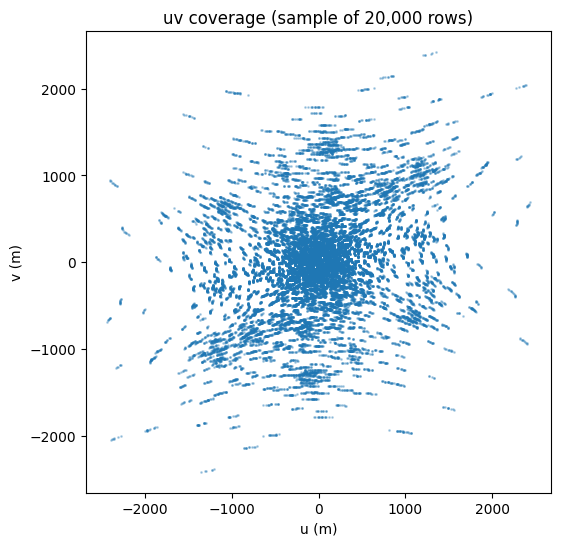

In [9]:
import matplotlib.pyplot as plt

sample = main_df.sample(20000, random_state=0)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample.u_m, sample.v_m, s=1, alpha=0.3, color="C0")
ax.scatter(-sample.u_m, -sample.v_m, s=1, alpha=0.3, color="C0")
ax.set_xlabel("u (m)"); ax.set_ylabel("v (m)")
ax.set_title("uv coverage (sample of 20,000 rows)")
ax.set_aspect("equal")

## 3. The per-channel columns (`DATA`, `FLAG`, `WEIGHT_SPECTRUM`)

Each MAIN-table row also carries a (2 polarizations × up to 303 channels) array in these columns — that's why they don't appear as ordinary cells above. Here's what *one row's* worth looks like, unpacked into its own small DataFrame.

Unpack row 0's `DATA`/`FLAG`/`WEIGHT_SPECTRUM` arrays into their own per-channel DataFrame. This row happens to be an autocorrelation (`antenna1 == antenna2 == 0`, zero `UVW`, fully flagged), which is why its amplitude is large and real (phase ≈ 0°) rather than a typical noisy cross-correlation visibility.

In [10]:
t = table()
t.open(MS_PATH)
row0 = 0
data = t.getcell("DATA", row0)              # shape (npol, nchan), complex
flag = t.getcell("FLAG", row0)
weight_spectrum = t.getcell("WEIGHT_SPECTRUM", row0)
t.close()

print("DATA shape for row 0 (npol, nchan):", data.shape)

chan_df = pd.DataFrame({
    "chan": np.arange(data.shape[1]),
    "amp_pol0": np.abs(data[0]),
    "phase_deg_pol0": np.angle(data[0], deg=True),
    "flag_pol0": flag[0],
    "weight_pol0": weight_spectrum[0],
})
chan_df.head(10)

DATA shape for row 0 (npol, nchan): (2, 291)


,chan,amp_pol0,phase_deg_pol0,flag_pol0,weight_pol0
0,0,9.077019,0.0,True,9450000.0
1,1,9.090832,0.0,True,9450000.0
2,2,9.104370,0.0,True,9450000.0
3,3,9.115622,0.0,True,9450000.0
4,4,9.132927,0.0,True,9450000.0
5,5,9.127617,0.0,True,9450000.0
6,6,9.112160,0.0,True,9450000.0
7,7,9.085464,0.0,True,9450000.0
8,8,9.046844,0.0,True,9450000.0
9,9,9.001822,0.0,True,9450000.0
